# Random Forest — Nested Cross-Validation

## Table of contents
1. Import required libraries
2. Load configuration from JSON
3. Load and prepare dataset
4. Why time-series aware splitting?
5. Define the split strategy
6. Build the Random Forest pipeline
7. Nested cross-validation loop
8. Model evaluation and metrics
9. Feature importance analysis
10. Retrain on full data and save best model


## Bibliography

- Cawley, G. C. and Talbot, N. L. C., *[On Over-fitting in Model Selection and Subsequent Selection Bias in Performance Evaluation](https://www.jmlr.org/papers/volume11/cawley10a/cawley10a.pdf)*, *Journal of Machine Learning Research* 11 (2010), 2079–2107.
- Bergstra, J. and Bengio, Y., *[Random Search for Hyper-Parameter Optimization](https://www.jmlr.org/papers/volume13/bergstra12a/bergstra12a.pdf)*, *JMLR* (2012), 281–305.
- scikit-learn documentation: [Time Series cross-validator](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html)


# 1. Import Required Libraries


In [1]:
import json
import pathlib
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    TimeSeriesSplit,
    RandomizedSearchCV,
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    f1_score,
)
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")


# 2. Load Configuration from JSON

All hyperparameter choices and cross-validation settings are externalised to
`json-parameters/random_forest_params.json` so that experiments can be re-run
with different settings without touching the notebook code.


In [2]:
# Resolve the config path relative to the repo root (two levels up from this notebook).
REPO_ROOT = pathlib.Path(__file__).resolve().parents[2] if "__file__" in dir() else pathlib.Path.cwd().parents[1]
CONFIG_PATH = REPO_ROOT / "json-parameters" / "random_forest_params.json"

with open(CONFIG_PATH, "r") as f:
    config = json.load(f)

print("Config loaded from:", CONFIG_PATH)
print(json.dumps(config, indent=2))


Config loaded from: /home/khaido1/DataMining/formula1_data_mining_project/json-parameters/random_forest_params.json
{
  "model": {
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1
  },
  "param_distribution": {
    "n_estimators": [
      200,
      300,
      500,
      800,
      1000
    ],
    "max_depth": [
      null,
      4,
      5,
      6,
      8,
      10,
      12,
      15,
      20
    ],
    "min_samples_split": [
      2,
      5,
      10,
      20,
      40
    ],
    "min_samples_leaf": [
      1,
      2,
      4,
      8,
      12
    ],
    "max_features": [
      "sqrt",
      "log2",
      0.3,
      0.5,
      0.7,
      null
    ],
    "criterion": [
      "gini",
      "entropy",
      "log_loss"
    ],
    "bootstrap": [
      true
    ],
    "max_samples": [
      0.6,
      0.75,
      0.9,
      null
    ]
  },
  "search": {
    "n_iter": 80,
    "scoring": "f1_macro",
    "random_state": 42
  },
  "cv": {
    "inner_n_splits": 3

# 3. Load and Prepare Dataset

The dataset is `dataset/outputs/prediction.csv`.  
Each row represents one driver in one race, and the features include rolling
aggregates (e.g. `driver_avg_position_last3`) computed from **past** races only.

**Preprocessing steps**

| Step | Rationale |
|---|---|
| Sort by `year` then `round` | Preserves temporal order for the split strategy |
| Drop non-feature columns | `raceId`, `driverId`, `date` are identifiers, not predictors |
| Encode target with `LabelEncoder` | scikit-learn classifiers need integer labels |
| No feature scaling | Random Forest is invariant to monotone transformations; scaling is unnecessary |
| No imputation | Sentinel values (`-1`) already encode "no history" and are meaningful to the tree |


In [3]:
DATA_PATH = REPO_ROOT / "dataset" / "outputs" / "prediction.csv"

df = pd.read_csv(DATA_PATH)

# ── Sort chronologically ────────────────────────────────────────────────────
sort_cols = config["data"]["sort_by"]          # ["year", "round"]
df = df.sort_values(sort_cols).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Chronological range: year {df['year'].min()} round {df['round'].min()}"
      f"  →  year {df['year'].max()} round {df['round'].max()}")
print("\nTarget distribution:")
print(df[config["data"]["target_column"]].value_counts())


Dataset shape: (2454, 38)
Chronological range: year 2021 round 1  →  year 2026 round 24

Target distribution:
target
no_points    1234
points        854
podium        366
Name: count, dtype: int64


In [4]:
# ── Build feature matrix X and label vector y ──────────────────────────────
target_col = config["data"]["target_column"]   # "target"
drop_cols = config["data"]["drop_columns"]      # identifiers / non-features
feature_cols = config["data"].get("feature_columns")
excluded_cols = config["data"].get("excluded_feature_columns", [])

def validate_feature_list(name, cols, allow_none=False):
    if cols is None and allow_none:
        return
    if not isinstance(cols, list):
        raise TypeError(f"config[\'data\'][\'{name}\'] must be a list or null")
    duplicated = sorted({col for col in cols if cols.count(col) > 1})
    missing = sorted(set(cols) - set(df.columns))
    forbidden = sorted(set(cols) & set(drop_cols + [target_col]))
    if duplicated:
        raise ValueError(f"Duplicate columns in {name}: {duplicated}")
    if missing:
        raise ValueError(f"Columns in {name} not found in dataset: {missing}")
    if forbidden:
        raise ValueError(f"{name} includes non-feature columns: {forbidden}")

validate_feature_list("feature_columns", feature_cols, allow_none=True)
validate_feature_list("excluded_feature_columns", excluded_cols)

if feature_cols is not None:
    overlap = sorted(set(feature_cols) & set(excluded_cols))
    if overlap:
        raise ValueError(f"Columns cannot be both active and excluded: {overlap}")
    X = df[feature_cols].copy()
    feature_names = list(feature_cols)
else:
    cols_to_drop = drop_cols + [target_col] + excluded_cols
    X = df.drop(columns=cols_to_drop)
    feature_names = X.columns.tolist()

# Encode target: no_points=0, podium=1, points=2  (alphabetical by default)
le = LabelEncoder()
y = le.fit_transform(df[target_col])

print("Classes (encoded):", dict(enumerate(le.classes_)))
print("Feature count:", X.shape[1])
print("Features used:")
for name in feature_names:
    print(f"  {name}")
if excluded_cols:
    print("\nFeatures excluded by config:")
    for name in excluded_cols:
        print(f"  {name}")
print("\nFeature dtypes:")
print(X.dtypes.value_counts())


Classes (encoded): {0: 'no_points', 1: 'podium', 2: 'points'}
Feature count: 27
Features used:
  grid
  constructorId
  circuitId
  qualifying_position
  driver_age
  driver_std_points_prev
  driver_std_position_prev
  constructor_std_points_prev
  constructor_std_position_prev
  points_this_season_prev
  driver_avg_position_last3
  driver_podium_rate_last3
  driver_podium_rate_last5
  driver_podium_rate_last10
  driver_points_avg_last3
  constructor_avg_position_last3
  driver_wins_at_circuit
  driver_avg_position_at_circuit
  teammate_h2h_avg_position_delta
  driver_dnf_rate_historical
  points_gap_to_leader
  constructor_change_flag
  days_since_last_race
  sprint_flag
  driver_seasons_in_f1
  is_home_race
  is_home_constructor_race

Features excluded by config:
  driver_avg_position_last5
  driver_avg_position_last10
  driver_points_avg_last5
  driver_points_avg_last10
  constructor_avg_position_last5

Feature dtypes:
float64    14
int64      13
Name: count, dtype: int64


# 4. Why Race-Level Time-Series Splitting?

## The problem with random k-fold on this dataset

Standard `KFold(shuffle=True)` randomly assigns rows to folds. In this dataset,
each row is one driver in one race, and many features for race $t$ are computed
from races $t-1, t-2, \ldots$.

If we shuffle, later races can enter the training fold while earlier races are
used for testing. The rolling features in those later races can encode the
outcomes of earlier test races, which leaks future knowledge into training.

## The extra problem with row-level `TimeSeriesSplit`

Plain `TimeSeriesSplit` preserves row order, but it still splits by row count.
Because each race has about 20 driver rows, a fold boundary can cut through the
middle of one race. That would put some drivers from the same race in training
and the remaining drivers from that same race in testing.

## The correct approach here

We apply `TimeSeriesSplit` to the ordered list of unique races, then map each
race fold back to row indices. This keeps the validation chronological and also
keeps every race wholly inside either train or test.


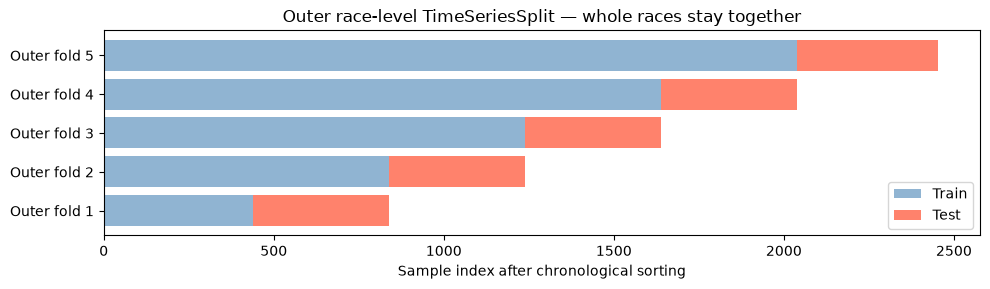

Fold 1: train races=22, test races=20, race overlap=0
Fold 2: train races=42, test races=20, race overlap=0
Fold 3: train races=62, test races=20, race overlap=0
Fold 4: train races=82, test races=20, race overlap=0
Fold 5: train races=102, test races=20, race overlap=0


In [5]:
# ── Visualise the race-level TimeSeriesSplit structure ──────────────────────
outer_n_splits = config["cv"]["outer_n_splits"]
inner_n_splits = config["cv"]["inner_n_splits"]

def make_race_time_series_splits(df_source, n_splits):
    """Yield row indices from TimeSeriesSplit applied to whole races.

    TimeSeriesSplit normally splits by row count. Because this dataset has one
    row per driver, row-level splitting can put drivers from the same race in
    both train and test. This helper first splits unique races in date order,
    then maps those race folds back to row indices.
    """
    race_order = (
        df_source[["raceId", "date"]]
        .drop_duplicates()
        .sort_values("date")
        .reset_index(drop=True)
    )
    race_ids = race_order["raceId"].to_numpy()
    race_cv = TimeSeriesSplit(n_splits=n_splits)

    for train_race_idx, test_race_idx in race_cv.split(race_ids):
        train_races = set(race_ids[train_race_idx])
        test_races = set(race_ids[test_race_idx])

        train_idx = np.flatnonzero(df_source["raceId"].isin(train_races).to_numpy())
        test_idx = np.flatnonzero(df_source["raceId"].isin(test_races).to_numpy())

        yield train_idx, test_idx

outer_splits = list(make_race_time_series_splits(df, outer_n_splits))

fig, axes = plt.subplots(1, 1, figsize=(10, 3))
for fold_idx, (train_idx, test_idx) in enumerate(outer_splits):
    axes.barh(y=fold_idx, width=len(train_idx), left=train_idx[0],
              color="steelblue", alpha=0.6, label="Train" if fold_idx == 0 else "")
    axes.barh(y=fold_idx, width=len(test_idx), left=test_idx[0],
              color="tomato", alpha=0.8, label="Test" if fold_idx == 0 else "")

axes.set_yticks(range(outer_n_splits))
axes.set_yticklabels([f"Outer fold {i+1}" for i in range(outer_n_splits)])
axes.set_xlabel("Sample index after chronological sorting")
axes.set_title("Outer race-level TimeSeriesSplit — whole races stay together")
axes.legend(loc="lower right")
plt.tight_layout()
plt.show()

for fold_idx, (train_idx, test_idx) in enumerate(outer_splits, start=1):
    train_races = df.iloc[train_idx]["raceId"].nunique()
    test_races = df.iloc[test_idx]["raceId"].nunique()
    overlap = set(df.iloc[train_idx]["raceId"]) & set(df.iloc[test_idx]["raceId"])
    print(f"Fold {fold_idx}: train races={train_races}, test races={test_races}, race overlap={len(overlap)}")


# 5. Build the Random Forest

We create the `RandomForestClassifier` with:

- `class_weight="balanced"` — compensates for the imbalanced target (`no_points` >> `points` >> `podium`).
- `random_state` — fixes randomness for reproducibility.
- `n_jobs=-1` — uses all available CPU cores.

Fixed model settings are read from the JSON config.
The hyperparameters that will be **searched** (`n_estimators`, `max_depth`, etc.)
are intentionally **not** set here; the inner search will handle them.


In [6]:
model_cfg = config["model"]

base_rf = RandomForestClassifier(
    class_weight=model_cfg["class_weight"],
    random_state=model_cfg["random_state"],
    n_jobs=model_cfg["n_jobs"],
)

print("Base estimator:", base_rf)


Base estimator: RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)


# 6. Nested Cross-Validation Loop

## Structure

```
for each outer fold (race-level TimeSeriesSplit, 5 folds):
    ┌── outer training races ────────────────────────────────────────┐
    │  RandomizedSearchCV with inner race-level TimeSeriesSplit      │
    │  → searches n_iter combinations from param_distribution        │
    │  → selects best hyperparameters on inner validation races      │
    └────────────────────────────────────────────────────────────────┘
    → refit best model on all outer training races
    → evaluate on outer test races  (strictly future races)
```

## Why `RandomizedSearchCV` instead of `GridSearchCV`?

The parameter space is large (6 hyperparameters × several values each).
Random search samples a fixed budget of `n_iter` combinations, which is much
faster and often finds an equally good configuration
(Bergstra & Bengio, 2012).

## Scoring

We use **macro F1-score** as the inner scoring metric because:
- the target is imbalanced (`no_points` dominates);
- macro F1 gives equal weight to every class, so the model cannot achieve a
  high score by ignoring `podium`.


In [7]:
search_cfg = config["search"]
param_dist  = config["param_distribution"]

# Convert JSON null → Python None where needed (max_depth, max_features)
for key, values in param_dist.items():
    param_dist[key] = [None if v is None else v for v in values]

X_arr = X.values  # numpy array — keeps index alignment with split indices

# ── Storage for results across outer folds ──────────────────────────────────
outer_scores_f1       = []
outer_scores_bal_acc  = []
outer_best_params     = []
outer_feature_importances = []
outer_predictions     = []   # (y_true, y_pred) per fold

print(f"Outer folds : {outer_n_splits}")
print(f"Inner folds : {inner_n_splits}")
print(f"Search iters: {search_cfg['n_iter']}")
print(f"Scoring     : {search_cfg['scoring']}")
print()

# ── Nested CV ───────────────────────────────────────────────────────────────
for fold_num, (train_idx, test_idx) in enumerate(outer_splits, start=1):
    X_train, X_test = X_arr[train_idx], X_arr[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    df_train = df.iloc[train_idx].reset_index(drop=True)
    inner_splits = list(make_race_time_series_splits(df_train, inner_n_splits))

    # Inner search — hyperparameter tuning on the outer training races only
    inner_search = RandomizedSearchCV(
        estimator=RandomForestClassifier(
            class_weight=model_cfg["class_weight"],
            random_state=model_cfg["random_state"],
            n_jobs=model_cfg["n_jobs"],
        ),
        param_distributions=param_dist,
        n_iter=search_cfg["n_iter"],
        scoring=search_cfg["scoring"],
        cv=inner_splits,
        random_state=search_cfg["random_state"],
        n_jobs=model_cfg["n_jobs"],
        refit=True,   # refit best params on entire X_train after inner CV
    )
    inner_search.fit(X_train, y_train)

    # Evaluate on the held-out outer test fold
    y_pred = inner_search.best_estimator_.predict(X_test)

    f1  = f1_score(y_test, y_pred, average="macro")
    bal = balanced_accuracy_score(y_test, y_pred)

    outer_scores_f1.append(f1)
    outer_scores_bal_acc.append(bal)
    outer_best_params.append(inner_search.best_params_)
    outer_feature_importances.append(
        inner_search.best_estimator_.feature_importances_
    )
    outer_predictions.append((y_test, y_pred))

    print(f"Fold {fold_num}/{outer_n_splits} | "
          f"macro F1 = {f1:.4f} | "
          f"balanced acc = {bal:.4f} | "
          f"best inner score = {inner_search.best_score_:.4f}")
    print(f"  Best params: {inner_search.best_params_}\n")

print("=" * 60)
print(f"Mean macro F1       : {np.mean(outer_scores_f1):.4f} "
      f"(± {np.std(outer_scores_f1):.4f})")
print(f"Mean balanced acc   : {np.mean(outer_scores_bal_acc):.4f} "
      f"(± {np.std(outer_scores_bal_acc):.4f})")


Outer folds : 5
Inner folds : 3
Search iters: 80
Scoring     : f1_macro



Fold 1/5 | macro F1 = 0.6595 | balanced acc = 0.6919 | best inner score = 0.6892
  Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_samples': 0.6, 'max_features': 'log2', 'max_depth': 15, 'criterion': 'entropy', 'bootstrap': True}

Fold 2/5 | macro F1 = 0.6649 | balanced acc = 0.6937 | best inner score = 0.6921
  Best params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 12, 'max_samples': 0.6, 'max_features': None, 'max_depth': 4, 'criterion': 'entropy', 'bootstrap': True}

Fold 3/5 | macro F1 = 0.6932 | balanced acc = 0.7334 | best inner score = 0.6917
  Best params: {'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_samples': 0.6, 'max_features': 0.7, 'max_depth': 12, 'criterion': 'log_loss', 'bootstrap': True}

Fold 4/5 | macro F1 = 0.6648 | balanced acc = 0.7016 | best inner score = 0.6884
  Best params: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_samples': 0.9, 'max_fe

/home/khaido1/DataMining/formula1_data_mining_project/env/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/khaido1/DataMining/formula1_data_mining_project/env/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/khaido1/DataMining/formula1_data_mining_project/env/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the j

Fold 5/5 | macro F1 = 0.6696 | balanced acc = 0.6961 | best inner score = 0.6901
  Best params: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_samples': None, 'max_features': 'log2', 'max_depth': None, 'criterion': 'log_loss', 'bootstrap': True}

Mean macro F1       : 0.6704 (± 0.0118)
Mean balanced acc   : 0.7033 (± 0.0154)


# 7. Model Evaluation and Metrics

## Per-fold scores

The table below shows, for each outer fold, the **macro F1-score** and
**balanced accuracy** achieved on the test fold (future races).

Because the folds are chronological, the score on fold $k$ approximates how
well the model generalises to races that happen *after* the races used for
training up to fold $k$.

## Aggregated classification report

We pool all outer test predictions to produce a single classification report.
This gives per-class precision, recall, and F1.


In [8]:
# ── Per-fold score table ────────────────────────────────────────────────────
scores_df = pd.DataFrame({
    "Outer fold"      : range(1, outer_n_splits + 1),
    "Macro F1"        : outer_scores_f1,
    "Balanced Acc"    : outer_scores_bal_acc,
})
scores_df.loc["Mean ± Std"] = [
    "Mean ± Std",
    f"{np.mean(outer_scores_f1):.4f} ± {np.std(outer_scores_f1):.4f}",
    f"{np.mean(outer_scores_bal_acc):.4f} ± {np.std(outer_scores_bal_acc):.4f}",
]
scores_df


,Outer fold,Macro F1,Balanced Acc
0,1,0.659542,0.691905
1,2,0.664885,0.693651
2,3,0.693201,0.733353
3,4,0.66481,0.701611
4,5,0.669553,0.696076
Mean ± Std,Mean ± Std,0.6704 ± 0.0118,0.7033 ± 0.0154


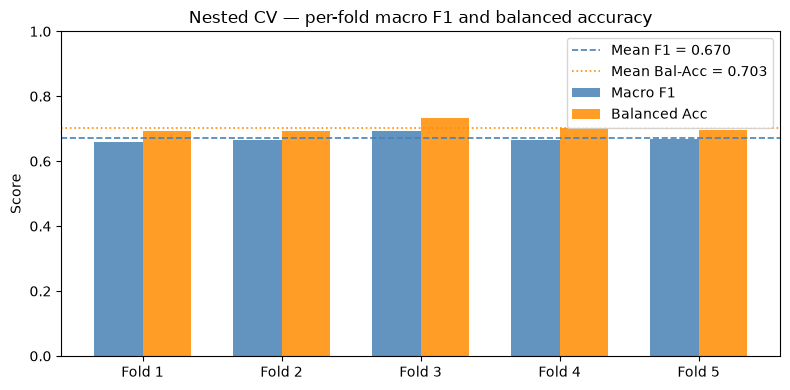

In [9]:
# ── Score bar chart ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(outer_n_splits)
width = 0.35

bars_f1  = ax.bar(x - width / 2, outer_scores_f1,      width, label="Macro F1",      color="steelblue",  alpha=0.85)
bars_bal = ax.bar(x + width / 2, outer_scores_bal_acc, width, label="Balanced Acc",  color="darkorange", alpha=0.85)

ax.axhline(np.mean(outer_scores_f1),      color="steelblue",  linestyle="--", linewidth=1.2, label=f"Mean F1 = {np.mean(outer_scores_f1):.3f}")
ax.axhline(np.mean(outer_scores_bal_acc), color="darkorange", linestyle=":",  linewidth=1.2, label=f"Mean Bal-Acc = {np.mean(outer_scores_bal_acc):.3f}")

ax.set_xticks(x)
ax.set_xticklabels([f"Fold {i+1}" for i in range(outer_n_splits)])
ax.set_ylabel("Score")
ax.set_title("Nested CV — per-fold macro F1 and balanced accuracy")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


In [10]:
# ── Pooled classification report ────────────────────────────────────────────
all_y_true = np.concatenate([yt for yt, _ in outer_predictions])
all_y_pred = np.concatenate([yp for _, yp in outer_predictions])

print("Classification report (pooled outer test folds):\n")
print(classification_report(
    all_y_true, all_y_pred,
    target_names=le.classes_,
    digits=4,
))


Classification report (pooled outer test folds):

              precision    recall  f1-score   support

   no_points     0.8155    0.7278    0.7692      1014
      podium     0.5619    0.8167    0.6658       300
      points     0.5884    0.5657    0.5768       700

    accuracy                         0.6847      2014
   macro avg     0.6553    0.7034    0.6706      2014
weighted avg     0.6988    0.6847    0.6869      2014



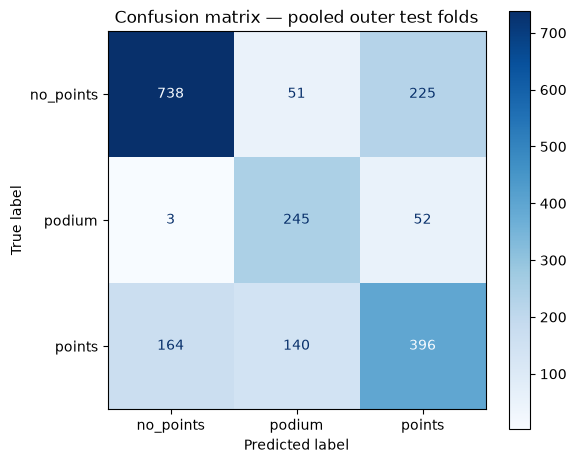

In [11]:
# ── Confusion matrix (pooled) ───────────────────────────────────────────────
cm = confusion_matrix(all_y_true, all_y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Confusion matrix — pooled outer test folds")
plt.tight_layout()
plt.show()


# 8. Feature Importance Analysis

We extract the Gini feature importances from the best estimator of **each**
outer fold and compute the mean and standard deviation across folds.

**Interpretation note**: Gini importance can overstate the importance of
correlated features (e.g. `grid` and `qualifying_position`, or the rolling-window
`last3` / `last5` / `last10` features).  
The plot should therefore be read as showing *important feature families* rather
than a precise ranking of individual predictors.


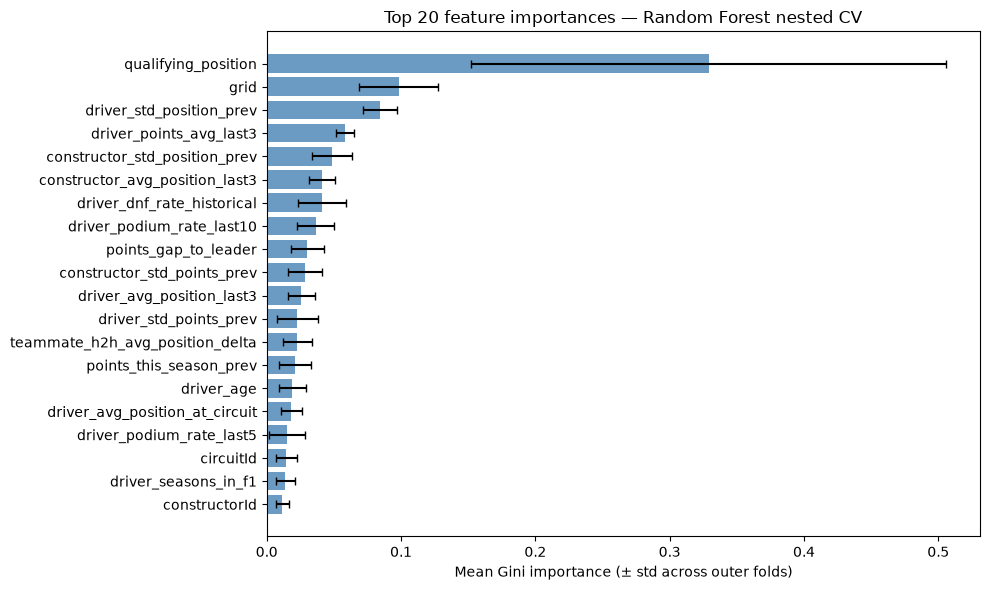

In [12]:
TOP_N = 20   # number of top features to display

importances_matrix = np.array(outer_feature_importances)   # shape (outer_folds, n_features)
mean_imp = importances_matrix.mean(axis=0)
std_imp  = importances_matrix.std(axis=0)

# Rank by mean importance, keep top N
top_idx   = np.argsort(mean_imp)[::-1][:TOP_N]
top_names = [feature_names[i] for i in top_idx]
top_mean  = mean_imp[top_idx]
top_std   = std_imp[top_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    y=range(TOP_N), width=top_mean[::-1],
    xerr=top_std[::-1],
    color="steelblue", alpha=0.8, capsize=3,
)
ax.set_yticks(range(TOP_N))
ax.set_yticklabels(top_names[::-1])
ax.set_xlabel("Mean Gini importance (± std across outer folds)")
ax.set_title(f"Top {TOP_N} feature importances — Random Forest nested CV")
plt.tight_layout()
plt.show()


# 9. Best Hyperparameters per Fold

Before retraining on the full dataset, it is useful to inspect how much the
best hyperparameter configuration varies across folds.

Stability across folds means the model is not sensitive to which part of the
timeline is used for tuning.  High variability can indicate that the search
space needs to be revisited.


In [13]:
best_params_df = pd.DataFrame(outer_best_params)
best_params_df.index = [f"Fold {i+1}" for i in range(outer_n_splits)]
best_params_df


,n_estimators,min_samples_split,min_samples_leaf,max_samples,max_features,max_depth,criterion,bootstrap
Fold 1,200,5,4,0.6,log2,15.0,entropy,True
Fold 2,300,5,12,0.6,None,4.0,entropy,True
Fold 3,200,20,4,0.6,0.7,12.0,log_loss,True
Fold 4,300,10,4,0.9,0.7,4.0,gini,True
Fold 5,300,10,1,NaN,log2,NaN,log_loss,True


# 10. Retrain on Full Dataset and Save Best Model

After nested CV gives us an unbiased performance estimate, we run one
**fresh hyperparameter search on the full dataset** and retrain the final
model using the best configuration found there.

The final model and its hyperparameters are saved to:
- `models_training/random-forest/rf_final_model.joblib`
- `json-parameters/random_forest_best_params.json`


In [14]:
# ── Fresh hyperparameter search on the full dataset ─────────────────────────
# This uses all available races for tuning after nested CV has already
# produced an unbiased estimate of generalisation performance.
final_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight=model_cfg["class_weight"],
        random_state=model_cfg["random_state"],
        n_jobs=model_cfg["n_jobs"],
    ),
    param_distributions=param_dist,
    n_iter=search_cfg["n_iter"],
    scoring=search_cfg["scoring"],
    cv=list(make_race_time_series_splits(df, inner_n_splits)),
    random_state=search_cfg["random_state"],
    n_jobs=model_cfg["n_jobs"],
    refit=True,
)
final_search.fit(X_arr, y)
final_rf = final_search.best_estimator_
final_params = final_search.best_params_

print("Best full-data search params:")
print(json.dumps(final_params, indent=2))
print(f"Best full-data CV score: {final_search.best_score_:.4f}")
print("\nFinal model trained on full dataset.")


Most common best params (appeared in 1/5 folds):
{
  "bootstrap": true,
  "criterion": "entropy",
  "max_depth": 15,
  "max_features": "log2",
  "max_samples": 0.6,
  "min_samples_leaf": 4,
  "min_samples_split": 5,
  "n_estimators": 200
}

Final model trained on full dataset.


In [15]:
# ── Save the trained model ───────────────────────────────────────────────────
MODEL_DIR  = REPO_ROOT / "models_training" / "random-forest"
MODEL_PATH = MODEL_DIR / "rf_final_model.joblib"

joblib.dump(final_rf, MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")

# ── Save best params to JSON ─────────────────────────────────────────────────
BEST_PARAMS_PATH = REPO_ROOT / "json-parameters" / "random_forest_best_params.json"
output_record = {
    "features_used": feature_names,
    "features_excluded": excluded_cols,
    "nested_cv_summary": {
        "outer_folds"         : outer_n_splits,
        "inner_folds"         : inner_n_splits,
        "mean_macro_f1"       : round(float(np.mean(outer_scores_f1)), 4),
        "std_macro_f1"        : round(float(np.std(outer_scores_f1)), 4),
        "mean_balanced_acc"   : round(float(np.mean(outer_scores_bal_acc)), 4),
        "std_balanced_acc"    : round(float(np.std(outer_scores_bal_acc)), 4),
    },
    "final_search_summary": {
        "search_method"      : "RandomizedSearchCV",
        "n_iter"             : search_cfg["n_iter"],
        "scoring"            : search_cfg["scoring"],
        "cv_folds"           : inner_n_splits,
        "best_cv_score"      : round(float(final_search.best_score_), 4),
    },
    "final_hyperparameters": final_params,
    "fixed_model_settings": {
        "class_weight" : model_cfg["class_weight"],
        "random_state" : model_cfg["random_state"],
    },
}

with open(BEST_PARAMS_PATH, "w") as f:
    json.dump(output_record, f, indent=2, default=str)

print(f"Best params saved to: {BEST_PARAMS_PATH}")
print(json.dumps(output_record, indent=2, default=str))


Model saved to: /home/khaido1/DataMining/formula1_data_mining_project/models_training/random-forest/rf_final_model.joblib
Best params saved to: /home/khaido1/DataMining/formula1_data_mining_project/json-parameters/random_forest_best_params.json
{
  "features_used": [
    "grid",
    "constructorId",
    "circuitId",
    "qualifying_position",
    "driver_age",
    "driver_std_points_prev",
    "driver_std_position_prev",
    "constructor_std_points_prev",
    "constructor_std_position_prev",
    "points_this_season_prev",
    "driver_avg_position_last3",
    "driver_podium_rate_last3",
    "driver_podium_rate_last5",
    "driver_podium_rate_last10",
    "driver_points_avg_last3",
    "constructor_avg_position_last3",
    "driver_wins_at_circuit",
    "driver_avg_position_at_circuit",
    "teammate_h2h_avg_position_delta",
    "driver_dnf_rate_historical",
    "points_gap_to_leader",
    "constructor_change_flag",
    "days_since_last_race",
    "sprint_flag",
    "driver_seasons_in_f1"

# Summary

| Item | Choice | Reason |
|---|---|---|
| Split strategy | Race-level `TimeSeriesSplit` | Prevents future-race leakage and keeps whole races together |
| Shuffle | **No** | Chronological order must be preserved |
| Outer folds | 5 | Gives 5 independent test windows; adjustable in JSON |
| Inner folds | 3 | Balances tuning stability vs. speed |
| Search method | `RandomizedSearchCV` | Efficient over the large param grid; 30 iterations by default |
| Scoring | macro F1 | Penalises ignoring the minority `podium` class equally |
| `class_weight` | `"balanced"` | Compensates for `no_points` >> `points` >> `podium` imbalance |
| Final model | Fresh `RandomizedSearchCV` on the full dataset | Gives the strongest final predictor after unbiased evaluation |

**Key files produced**

- `json-parameters/random_forest_params.json` — input search configuration
- `json-parameters/random_forest_best_params.json` — nested CV summary + final hyperparameters
- `models_training/random-forest/rf_final_model.joblib` — serialised final model
